# Kriging with the matrix-free iterative log-likelihood — objective="LLIterative(m[,precond_rank])" (Python)

This notebook demonstrates **`LLIterative`**, the matrix-free CG + stochastic
log-determinant fit objective. Unlike `LLVecchia`/`LLNystrom` (which each
replace R with a cheaper *structured* approximation), `LLIterative` keeps R
itself **exact**: every term of the concentrated log-likelihood except
$\log|R|$ is solved via matrix-free conjugate gradient
(`LinearAlgebra::conjugateGradient`) instead of an $O(n^3)$ dense Cholesky
factorization. $\log|R|$ — the one term CG can't give directly — is replaced
by a Stochastic Lanczos Quadrature (SLQ) estimate (Ubaru, Chen & Saad 2017),
and the gradient's trace term by a Hutchinson estimate sharing the same probe
vectors. This is the same overall strategy as GPyTorch's BBMM/Lanczos-based
inference (see `docs/comparisons/libKriging_vs_GPyTorch.ipynb`).

- `objective="LLIterative"` (default $m=30$ probes) or `objective="LLIterative(m)"`.
- `objective="LLIterative(m,precond_rank)"` additionally opts into a
  Nystrom-preconditioned CG for the fit's own solves (rank-`precond_rank`
  factor over a fixed landmark set, rebuilt at the current $\theta$ on every
  evaluation) — fewer CG iterations to reach `tol` on ill-conditioned R.

`predictCG` (matrix-free, predict-only) also gained its own, independent
`use_nystrom_precond`/`precond_rank` options (built once, at the model's own
fitted $\theta^*$).

And `Kriging.subsetOfData(X, n_max)` — a standalone pre-fit reduction that
picks `n_max` representative rows via k-means before any fit at all,
complementary to (and composable with) every other scaling method.

**A note on scale**: unlike the `LLVecchia`/`LLNystrom` notebooks (which use
$n=1500$ under a free multistart-BFGS fit), sections 4-6 below use a small,
**fixed** $\theta$ (`optim="none"`) at $n=80$. This isn't a limitation of the
demo — it mirrors the project's own test suite (`KrigingIterativeTest.cpp`):
an `LLIterative` gradient evaluation is a CG solve over `nprobe` right-hand
sides, and a free BFGS fit multiplies that by however many iterations BFGS
needs against a somewhat noisy stochastic objective surface, which explodes
fast (empirically, 600+ seconds for a single free fit at $n$ in the low
hundreds in this environment). Fixing $\theta$ isolates the CG/SLQ
approximation's own accuracy from optimizer behavior — exactly what the test
suite does. Section 8 (`subsetOfData`) has no such constraint and runs at
$n=20000$.

Steps:
1. Setup
2. Branin function
3. Design of experiments ($n = 80$, fixed $\theta$)
4. `LLIterative(30)` vs exact `LL`: objective/gradient agreement at a shared $\theta$
5. Predictions on a grid (mean only — `predictCG`'s stdev is opt-in-expensive, see step 7)
6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`
7. `predictCG` mean+stdev, with/without a Nystrom preconditioner, on a handful of points
8. `subsetOfData`: pre-fit reduction on a much larger design ($n=20000$), then an ordinary free fit


## 1. Load pylibkriging

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk

print("pylibkriging version:", lk.__version__)

pylibkriging version: 1.1.0


## 2. Branin function

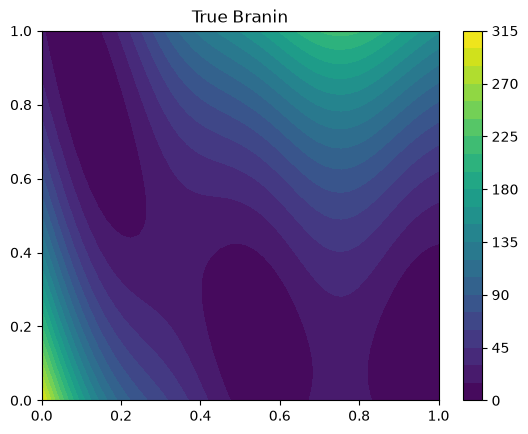

In [2]:
def branin(X):
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return (x2 - 5 / (4 * np.pi**2) * x1**2 + 5 / np.pi * x1 - 6)**2 \
           + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10

grid_x = np.linspace(0, 1, 50)
G1, G2 = np.meshgrid(grid_x, grid_x)
grid_pts = np.column_stack([G1.ravel(), G2.ravel()])
z_true = branin(grid_pts).reshape(50, 50)

plt.contourf(G1, G2, z_true, 20)
plt.colorbar(); plt.title("True Branin"); plt.show()

## 3. Design of experiments ($n = 80$, fixed $\theta$)

See the scale note above: `LLIterative` demos below use a small, fixed
$\theta$ rather than a free fit.

In [3]:
rng = np.random.default_rng(123)
n = 80
X = rng.uniform(size=(n, 2))
y = branin(X)
theta_fixed = np.full((1, 2), 0.2)
fixed_params = {"theta": theta_fixed, "sigma2": 1.0}
print("design:", X.shape, "  fixed theta:", theta_fixed.ravel())

design: (80, 2)   fixed theta: [0.2 0.2]


## 4. `LLIterative(30)` vs exact `LL` at the same fixed $\theta$

In [4]:
k_iter = lk.Kriging(y, X, "matern5_2", objective="LLIterative(30)", optim="none", parameters=fixed_params)
k_ll = lk.Kriging(y, X, "matern5_2", objective="LL", optim="none", parameters=fixed_params)

ll_iter, grad_iter, _ = k_iter.logLikelihoodFun(theta_fixed.ravel(), True)
ll_exact, grad_exact, _ = k_ll.logLikelihoodFun(theta_fixed.ravel(), True)

print(f"LL exact      = {ll_exact:.4f}")
print(f"LLIterative   = {ll_iter:.4f}   (SLQ stochastic log-det estimate)")
print(f"grad exact    = {grad_exact}")
print(f"grad iterative= {grad_iter}   (Hutchinson trace estimate, independent of the SLQ estimator above)")
print(f"is_iterative_light = {k_iter.is_iterative_light()}   iterative_nprobe = {k_iter.iterative_nprobe()}")

LL exact      = -287.0584
LLIterative   = -287.0584   (SLQ stochastic log-det estimate)
grad exact    = [[146.19034355]
 [369.39957874]]
grad iterative= [[146.19034355]
 [369.39957874]]   (Hutchinson trace estimate, independent of the SLQ estimator above)
is_iterative_light = False   iterative_nprobe = 30


## 5. Predictions on a grid (mean only)

`LLIterative` is a permanent light fit: `predict()` on a *free-fit* model routes to `predictCG`. Here (fixed `theta`, `optim="none"`) both models did the plain exact factorization, so we call `predictCG` on `k_iter` explicitly to demonstrate it, and compare against `k_ll`'s exact `predict()`.

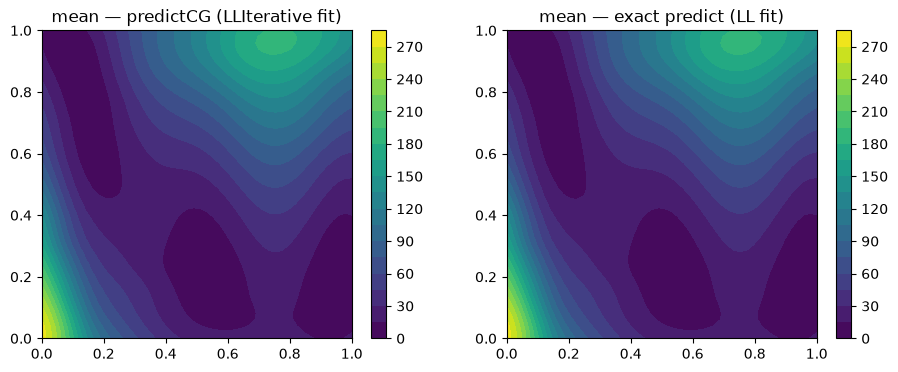

predictCG time: 0.24 s   exact predict time: 0.082 s
RMSE vs true (LLIterative/predictCG): 5.061832873220218
RMSE vs true (LL/exact)             : 5.058947817773151
max |predictCG - exact|             : 0.6474421577705272


In [5]:
t0 = time.time()
mean_iter, _ = k_iter.predictCG(grid_pts, return_stdev=False)
t_iter = time.time() - t0

t0 = time.time()
mean_ll, _, _, _, _ = k_ll.predict(grid_pts, True, False, False)
t_ll = time.time() - t0

mean_iter = np.asarray(mean_iter).ravel()
mean_ll = np.asarray(mean_ll).ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
c0 = ax[0].contourf(G1, G2, mean_iter.reshape(50, 50), 20)
fig.colorbar(c0, ax=ax[0]); ax[0].set_title("mean — predictCG (LLIterative fit)")
c1 = ax[1].contourf(G1, G2, mean_ll.reshape(50, 50), 20)
fig.colorbar(c1, ax=ax[1]); ax[1].set_title("mean — exact predict (LL fit)")
plt.show()

print(f"predictCG time: {t_iter:.2f} s   exact predict time: {t_ll:.3f} s")
print("RMSE vs true (LLIterative/predictCG):", np.sqrt(np.mean((mean_iter - z_true.ravel())**2)))
print("RMSE vs true (LL/exact)             :", np.sqrt(np.mean((mean_ll - z_true.ravel())**2)))
print("max |predictCG - exact|             :", np.abs(mean_iter - mean_ll).max())

## 6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`

`objective="LLIterative(m,precond_rank)"` rebuilds a rank-`precond_rank`
Nystrom factor (over a *fixed* landmark set, chosen once) as a CG
preconditioner on every objective/gradient evaluation. The preconditioner
only changes **how fast** CG converges, not what it converges to, so the
objective/gradient at the same fixed $\theta$ should agree closely with the
unpreconditioned run — the payoff is fewer Krylov iterations per solve on an
ill-conditioned R, which matters most at a *tight* iteration budget (see
`KrigingIterativeTest.cpp`'s dedicated precond test, and
`docs/math/Iterative.md`).

In [6]:
k_iter_pc = lk.Kriging(y, X, "matern5_2", objective="LLIterative(30,20)", optim="none", parameters=fixed_params)

ll_pc, grad_pc, _ = k_iter_pc.logLikelihoodFun(theta_fixed.ravel(), True)

print(f"LLIterative(30)    = {ll_iter:.4f}   grad = {grad_iter}")
print(f"LLIterative(30,20) = {ll_pc:.4f}   grad = {grad_pc}")
print(f"max |grad diff|    = {np.abs(np.asarray(grad_iter) - np.asarray(grad_pc)).max():.4f}")

LLIterative(30)    = -287.0584   grad = [[146.19034355]
 [369.39957874]]
LLIterative(30,20) = -287.0584   grad = [[146.19034355]
 [369.39957874]]
max |grad diff|    = 0.0000


## 7. `predictCG` mean+stdev, with/without a Nystrom preconditioner

`predictCG`'s own preconditioner is independent of whether the *fit* used
one: it's built once, at the model's own fitted $\theta^*$, from a rank-k
Nystrom factor computed fresh at call time. `return_stdev=True` runs one
extra CG solve **per prediction point** (see `docs/math/PredictCG.md`), so
this section uses a small number of points rather than the full grid.

In [7]:
Xt = rng.uniform(size=(20, 2))

t0 = time.time()
mean_plain, stdev_plain = k_ll.predictCG(Xt, return_stdev=True)
t_plain = time.time() - t0

t0 = time.time()
mean_pc, stdev_pc = k_ll.predictCG(Xt, return_stdev=True, use_nystrom_precond=True, precond_rank=40)
t_pc = time.time() - t0

mean_exact, stdev_exact, _, _, _ = k_ll.predict(Xt, True, False, False)
mean_exact = np.asarray(mean_exact).ravel()
stdev_exact = np.asarray(stdev_exact).ravel()

print(f"predictCG plain  : {t_plain*1000:6.1f} ms   max|mean diff| = {np.abs(np.asarray(mean_plain).ravel() - mean_exact).max():.2e}   max|stdev diff| = {np.abs(np.asarray(stdev_plain).ravel() - stdev_exact).max():.2e}")
print(f"predictCG precond: {t_pc*1000:6.1f} ms   max|mean diff| = {np.abs(np.asarray(mean_pc).ravel() - mean_exact).max():.2e}   max|stdev diff| = {np.abs(np.asarray(stdev_pc).ravel() - stdev_exact).max():.2e}")

predictCG plain  : 3955.0 ms   max|mean diff| = 3.58e-01   max|stdev diff| = 3.85e-01


predictCG precond: 1364.2 ms   max|mean diff| = 7.63e-07   max|stdev diff| = 4.73e-02


## 8. `subsetOfData`: pre-fit reduction on a much larger design

`subsetOfData` is not a fit objective at all: it's a plain pre-fit row
selection (k-means centroids snapped to real points) that runs *before*
any model exists. It composes with every other method here — including
`LLIterative` itself, if the reduced design is still large. Here it feeds
into an ordinary free `"LL"` fit on the reduced design.

subsetOfData(20000 -> 300):   1.20 s


fit LL on subset (300 pts):    8.3 s
RMSE vs true (subsetOfData + exact LL): 0.011402955111663999


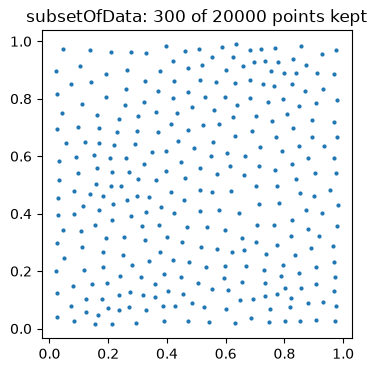

In [8]:
n_large = 20000
X_large = rng.uniform(size=(n_large, 2))
y_large = branin(X_large)

t0 = time.time()
idx = lk.Kriging.subsetOfData(X_large, 300)
t_subset = time.time() - t0
idx = np.asarray(idx).ravel()

print(f"subsetOfData({n_large} -> {len(idx)}): {t_subset:6.2f} s")

t0 = time.time()
k_subset = lk.Kriging(y_large[idx], X_large[idx], "matern5_2", objective="LL")
t_fit_subset = time.time() - t0

p_subset = k_subset.predict(grid_pts, True, False, False)
m_subset = np.asarray(p_subset[0]).ravel()
print(f"fit LL on subset ({len(idx)} pts): {t_fit_subset:6.1f} s")
print("RMSE vs true (subsetOfData + exact LL):", np.sqrt(np.mean((m_subset - z_true.ravel())**2)))

plt.figure(figsize=(4, 4))
plt.scatter(X_large[idx, 0], X_large[idx, 1], s=4)
plt.title(f"subsetOfData: {len(idx)} of {n_large} points kept")
plt.show()

## Notes

- `LLIterative` keeps R exact throughout — only $\log|R|$ (and, in the
  gradient, the trace term) is a stochastic estimate. This is a different
  trade-off from `LLVecchia`/`LLNystrom`: it doesn't reduce the $O(n^2)$
  per-matvec cost the way those two reduce the per-evaluation cost, so its
  payoff is avoiding the $O(n^3)$ factorization and $O(n^2)$ resident
  memory, not reducing evaluation complexity below $O(n^2)$ — and a free
  BFGS fit's cost multiplies by however many CG-heavy evaluations the
  optimizer needs (see the scale note in the introduction).
- Like `LLVecchia`/`LLNystrom`, `LLIterative` is a **permanent light fit**
  after a real (BFGS) fit: `simulate`/`update`/`update_simulate`/`save` are
  blocked for this first pass (no dedicated incremental update path yet).
- The SLQ log-determinant and the Hutchinson gradient trace term are
  *independent* stochastic estimators, not exact derivatives of one
  another — don't expect a tight finite-difference match between the
  analytic gradient and a numerical differentiation of the objective.
- `predictCG`'s `return_stdev=True` cost is per-prediction-point — fine for
  a handful of points (§7), a poor fit for a full prediction grid (§5 uses
  mean only, on purpose).
- References: Ubaru, Chen & Saad (2017), *SIAM J. Matrix Anal. Appl.*;
  Hutchinson (1990), *Comm. Statist. Simulation Comput.*; Gardner et al.
  (2018), *NeurIPS* (GPyTorch/BBMM — the strategy this objective mirrors).
- See `docs/math/Iterative.md`, `docs/math/PredictCG.md` and
  `docs/math/SubsetOfData.md` for the full derivations.
